In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *
from MODELS.teamInfo import *


In [2]:
modelPTS = joblib.load('../MODELS/Models/xgbPTSModelNoOppStats.pkl')
featuresPTS = joblib.load('../MODELS/Models/topPTSfeaturesNoOppStats.pkl')
# modelREB = joblib.load('../MODELS/Models/xgbREBModel.pkl')
# featuresREB = joblib.load('../MODELS/Models/topREBfeatures.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')
s24_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')

dfPTS = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
date = '2024-11-30'
# dfREB = pd.concat([s25_reb, s24_reb]).sort_values(by='GAME_DATE')

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
trailRun = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points') & (backtestData['GAME_DATE'] == date)]
trailRun

C:\Users\alexg\AppData\Local\Temp\ipykernel_26656\1702020630.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
20752,20752,20752,20752,Tidjane Salaun,player_points,prizepicks,under,13.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20753,20753,20753,20753,Josh Green,player_points,prizepicks,under,10.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20754,20754,20754,20754,Bogdan Bogdanovic,player_points,prizepicks,under,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20755,20755,20755,20755,Bogdan Bogdanovic,player_points,prizepicks,over,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
20756,20756,20756,20756,De'Andre Hunter,player_points,prizepicks,over,15.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21051,21051,21051,21051,Dereck Lively II,player_points,prizepicks,over,9.0,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21055,21055,21055,21055,Quentin Grimes,player_points,prizepicks,over,11.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21065,21065,21065,21065,Collin Sexton,player_points,prizepicks,under,18.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,under
21066,21066,21066,21066,Daniel Gafford,player_points,prizepicks,over,10.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over


In [6]:
# Make sure this is correct:
results = backtestPairs(dfPTS, backtestData, date, modelPTS, featuresPTS, edge_threshold=4.5, top_n=10, simulations=10000, stat_col='PTS')
results

Processing pairs...


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,date
0,Alex Sarr,Cody Martin,OVER,UNDER,10.5,9.5,17.90,2.90,13,9,7.40,-6.60,1,1,1,1,1.708,0.9025,2024-11-30
1,Alex Sarr,Quentin Grimes,OVER,OVER,10.5,11.5,17.90,16.77,13,21,7.40,5.27,1,1,1,1,1.547,0.8489,2024-11-30
2,Cody Martin,Quentin Grimes,UNDER,OVER,9.5,11.5,2.90,16.77,9,21,-6.60,5.27,1,1,1,1,1.547,0.8489,2024-11-30
3,Cody Martin,Daniel Gafford,UNDER,OVER,9.5,10.5,2.90,14.23,9,10,-6.60,3.73,1,0,0,0,1.487,0.8289,2024-11-30
4,Alex Sarr,Daniel Gafford,OVER,OVER,10.5,10.5,17.90,14.23,13,10,7.40,3.73,1,0,0,0,1.487,0.8289,2024-11-30
5,Alex Sarr,Brandon Miller,OVER,UNDER,10.5,26.5,17.90,21.83,13,20,7.40,-4.67,1,1,1,1,1.474,0.8246,2024-11-30
6,Cody Martin,Collin Sexton,UNDER,OVER,9.5,18.5,2.90,23.49,9,26,-6.60,4.99,1,1,1,1,1.471,0.8236,2024-11-30
7,Alex Sarr,Collin Sexton,OVER,OVER,10.5,18.5,17.90,23.49,13,26,7.40,4.99,1,1,1,1,1.471,0.8236,2024-11-30
8,Brandon Miller,Quentin Grimes,UNDER,OVER,26.5,11.5,21.83,16.77,20,21,-4.67,5.27,1,1,1,1,1.327,0.7756,2024-11-30
9,Collin Sexton,Quentin Grimes,OVER,OVER,18.5,11.5,23.49,16.77,26,21,4.99,5.27,1,1,1,1,1.324,0.7748,2024-11-30


In [26]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 8, Win Rate: 80.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 3, Wins: 3, Win Rate: 100.00%


In [7]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(dfPTS, backtestData, modelPTS, featuresPTS, date, edge_threshold=5, top_n=10, simulations=10000, stat_col='PTS')
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-24... 2/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-25... 3/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-26... 4/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-27... 5/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-28... 6/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-29... 7/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-30... 8/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-10-31... 9/162
  ✗ Error: '<' not supported between instances of 'str' and 'XGBRegressor'
Processing 2024-11-01... 10/162
  ✗ Error: '<'

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,410
   Wins: 667
   Hit Rate: 47.30%
   Total Profit: $2,955.00
   Total Staked: $7,050.00
   ROI: 41.91%
   Volatility: $42.16
   Max Drawdown: $-170.00
   Sharpe Ratio: 5.903

 RECOMMENDED BETS ANALYSIS (Edge > 5):
   Total Bets: 407
   Wins: 220
   Hit Rate: 54.05%
   Total Profit: $1,265.00
   Total Staked: $2,035.00
   ROI: 62.16%
   Volatility: $24.89
   Max Drawdown: $-110.00
   Sharpe Ratio: 4.985


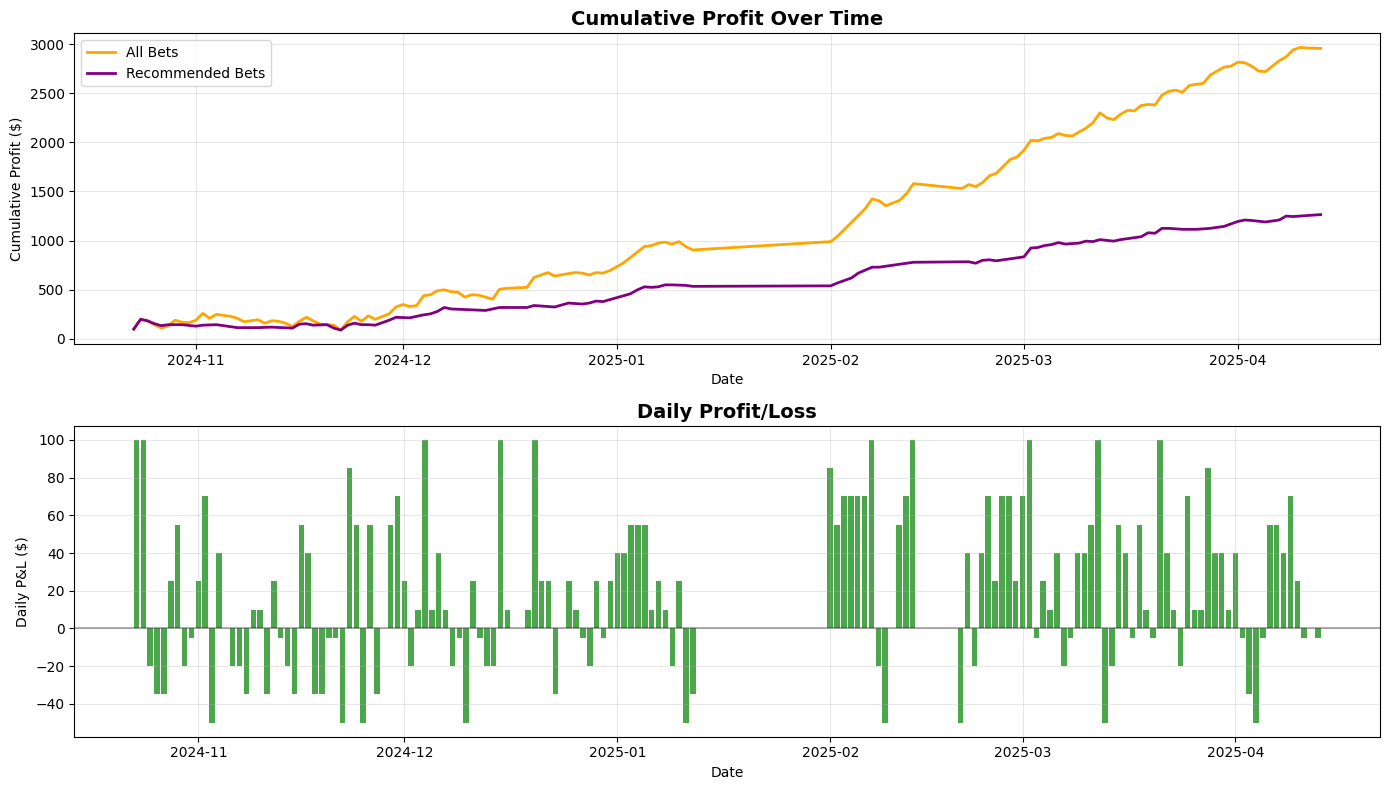

In [5]:
edge = 5
final_results = pd.read_csv('NoOppStats.csv')
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()